# Exploration initiale des données (EDA - partie 2)

Calculer des statistiques descriptives par colonne. Étudier la distribution des variables clés (ports, protocoles, statuts). Visualiser avec matplotlib/seaborn. Identifier les déséquilibres de classes si des labels sont présents.

## Importation des librairies

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
chemin_CICIDS = '../Data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
chemin_UNSW   = '../Data/UNSW-NB15_1.csv'
chemin_LOGS   = '../Data/cybersecurity_threat_detection_logs.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW, low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS, low_memory=False)


## Dataset 1 : CIC-IDS-2017

### 1.1 Statistiques descriptives

In [3]:
# Statistiques descriptives des colonnes numériques
df_cicids.describe()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


On remarque que la grande majorité du trafic cible le port 80 (HTTP) comme le confirme la médiane à 80. Cependant la moyenne est bien plus élevée à 8879, ce qui signifie que certaines connexions utilisent des ports très élevés jusqu'à 65532. Ces ports élevés sont souvent utilisés par les outils d'attaque DDoS.
La moitié des flux durent moins de 1,45 seconde. On remarque une valeur minimale à -1 qui est aberrante qui sera traitée lors du nettoyage. Le maximum atteint environ 120 secondes, ce qui représente des connexions bien plus longues que la normale.
En moyenne seulement 5 paquets sont envoyés dans le sens aller et 4 dans le sens retour, mais le maximum atteint respectivement 1932 et 2942 paquets. L'écart-type très élevé (15 et 21) par rapport à la moyenne cette différence révèle quelques connexions qui génèrent un volume massif de paquets pouvant être la signature caractéristique d'une attaque DDoS.
La médiane de la taille totale des paquets envoyés est seulement de 30 octets ce qui indique que la majorité du trafic est composé de petits paquets refletant un déséquilibre qui sera corrigé lors du nettoyage.
Concernant le déséquilibre des classes, le dataset est très déséquilibré avec une large majorité de trafic DDoS face à une minorité de trafic bénin. Ce déséquilibre devra être traité avant la modélisation.




### 1.2 Distribution des variables clés


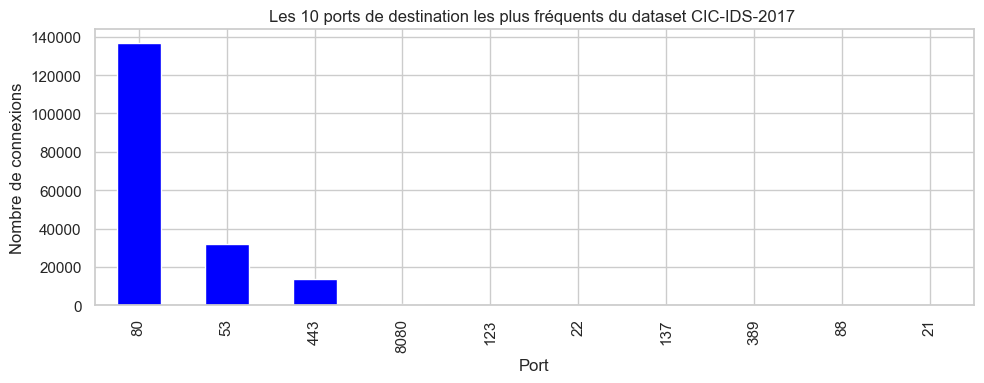

In [120]:
fig, ax = plt.subplots()
ports = df_cicids[' Destination Port'].value_counts().head(10) #10 ports les plus féquents 
ports.plot(kind='bar', color='blue')
ax.set_title('Les 10 ports de destination les plus fréquents du dataset CIC-IDS-2017 ')
ax.set_xlabel('Port')
ax.set_ylabel('Nombre de connexions')
plt.tight_layout()
plt.show()

Le port 80 (HTTP) est largement au dessus des autres ports avec environ 135 000 connexions, ce qui est cohérent avec une attaque DDoS qui cible massivement les serveurs web. Les ports 53 (DNS) et 443 (HTTPS) arrivent loin derrière, et les 7 autres ports sont quasi-négligeables.

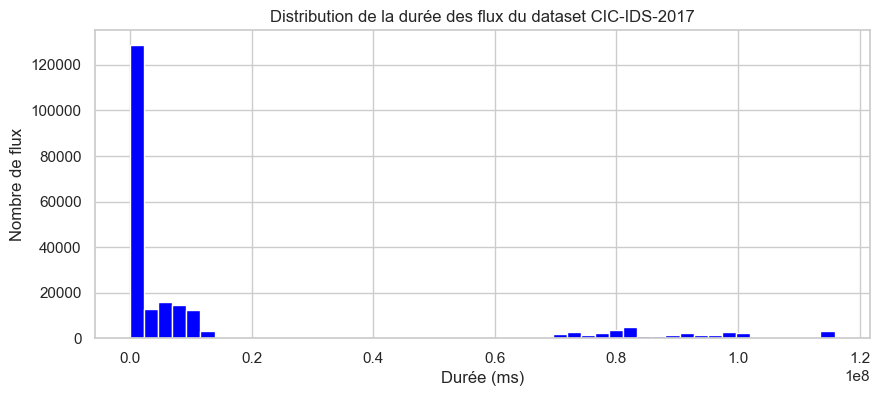

In [101]:
# Distribution de la durée des flux (Flow Duration)
fig, ax = plt.subplots()
df_cicids[' Flow Duration'].clip(upper=df_cicids[' Flow Duration'].quantile(0.99)).hist(bins=50, color='blue')
ax.set_title('Distribution de la durée des flux du dataset CIC-IDS-2017')
ax.set_xlabel('Durée (ms)')
ax.set_ylabel('Nombre de flux')
plt.show()

On remarque que la grande majorité des flux durent moins de 0,02 secondes. On retrouve quelques flux jusqu'à 1,2×10⁸ ms qui peuvent représenter des connexions de streaming (vidéo, audio) qui restent actives le temps du transfert ou encore des connexions de base de données persistantes entre un serveur et ses clients.


### 1.3 Déséquilibre des classes

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


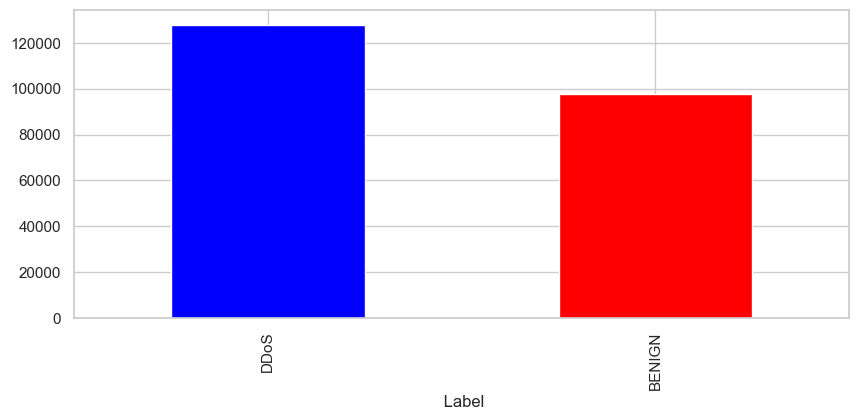

In [113]:
print(df_cicids[' Label'].value_counts())
label = df_cicids[' Label'].value_counts().plot(kind='bar',color=['blue', 'red'])
ax.set_title('Déséquilibre des classes du dataset CIC-IDS-2017')
ax.set_xlabel('Label')
ax.set_ylabel('Nombre de lignes')
plt.show()

Le dataset présente un déséquilibre assez léger avec 128 027 flux DDoS (57%) contre 97 718 flux bénins (43%). 


## 2. UNSW-NB15

### 2.1 Statistiques descriptives

In [114]:
df_unsw.columns = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur',
    'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service',
    'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb',
    'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt',
    'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
    'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'
]
df_unsw = pd.read_csv(chemin_UNSW, names=df_unsw.columns, low_memory=False)
print(df_unsw.columns.tolist())

['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [115]:
# Statistiques descriptives des colonnes numériques
df_unsw.describe()

,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,Sload,Dload,Spkts,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
count,700000.000000,7.000000e+05,7.000000e+05,700000.000000,700000.000000,700000.000000,700000.000000,7.000000e+05,7.000000e+05,700000.000000,...,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,0.863392,5.009643e+03,4.833044e+04,38.513859,31.980787,6.330453,21.326301,6.024278e+06,3.011026e+06,41.746700,...,0.019623,0.031116,6.380244,6.034167,4.153237,4.668596,1.685499,1.401911,2.188107,0.031736
std,25.935783,4.489871e+04,1.860517e+05,39.996983,30.450778,18.855991,64.733418,5.181495e+07,4.499955e+06,80.198772,...,0.138700,0.278212,5.075149,4.635611,3.740440,4.189669,1.871053,1.426014,2.211200,0.175296
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.003931,4.240000e+02,3.040000e+02,31.000000,29.000000,0.000000,0.000000,7.885879e+04,7.640435e+04,4.000000,...,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,0.027594,2.024000e+03,3.380000e+03,31.000000,29.000000,4.000000,5.000000,5.362718e+05,6.686759e+05,16.000000,...,0.000000,0.000000,5.000000,5.000000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000
75%,0.346519,3.806000e+03,2.243200e+04,31.000000,29.000000,7.000000,16.000000,1.078489e+06,3.856223e+06,52.000000,...,0.000000,0.000000,9.000000,8.000000,5.000000,6.000000,2.000000,1.000000,3.000000,0.000000
max,8786.637695,1.367739e+07,1.465542e+07,255.000000,254.000000,5096.000000,5483.000000,5.268000e+09,1.287619e+08,10200.000000,...,1.000000,8.000000,44.000000,42.000000,42.000000,50.000000,36.000000,34.000000,38.000000,1.000000


Le dataset UNSW-NB15 compte 700 000 connexions sans aucune valeur manquante.
La durée moyenne des connexions est de 0,86 seconde mais le maximum atteint 8786 secondes, ce qui signifie que quelques connexions sont extrêmement longues et tirent la moyenne vers le haut. L'écart-type très élevé (25,9) par rapport à la moyenne.
Les octets échangés possèdent des écarts-types très élevés par rapport aux médianes. En effet certaines connexions transfèrent des millions d'octets pendant que la majorité en transfère très peu.
Les valeurs TTL source (sttl) et destination (dttl) sont très stables avec une médiane à 31 et 29 et peu de variation, ce qui est cohérent avec des valeurs TTL standards dans un environnement réseau contrôlé.
Concernant le déséquilibre des classes, la colonne Label a une moyenne à 0,03 ce qui confirme que seulement 3% des connexions sont des attaques. Ce fort déséquilibre devra être traité avant la modélisation.

### 2.2 Distribution des variables clés

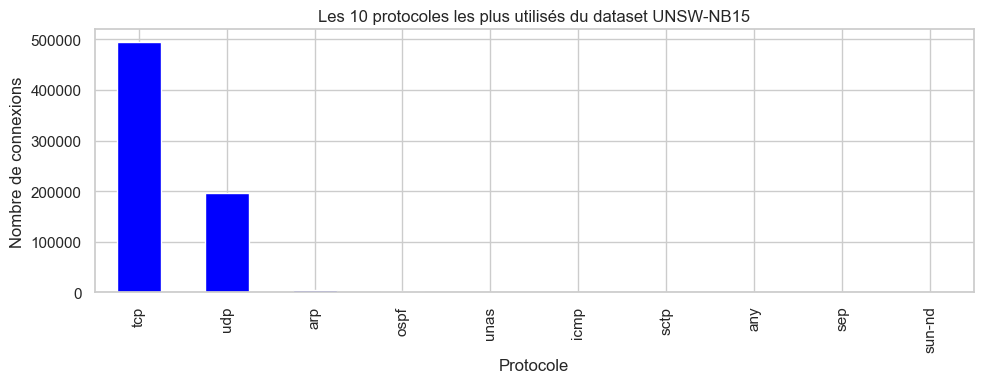

In [98]:
# Distribution des protocoles
fig, ax = plt.subplots()
protocol= df_unsw['proto'].value_counts().head(10)
protocol.plot(kind='bar', color='blue')
ax.set_title('Les 10 protocoles les plus utilisés du dataset UNSW-NB15')
ax.set_xlabel('Protocole')
ax.set_ylabel('Nombre de connexions')
plt.show()

On remarque que le protocole TCP domine largement avec environ 500 000 connexions, suivi d'UDP avec environ 200 000. Les 8 autres protocoles (ARP, OSPF, ICMP…) sont quasiment absents. Cela est cohérent avec le trafic réseau réel où TCP est le protocole dominant pour la grande majorité des communications internet. 

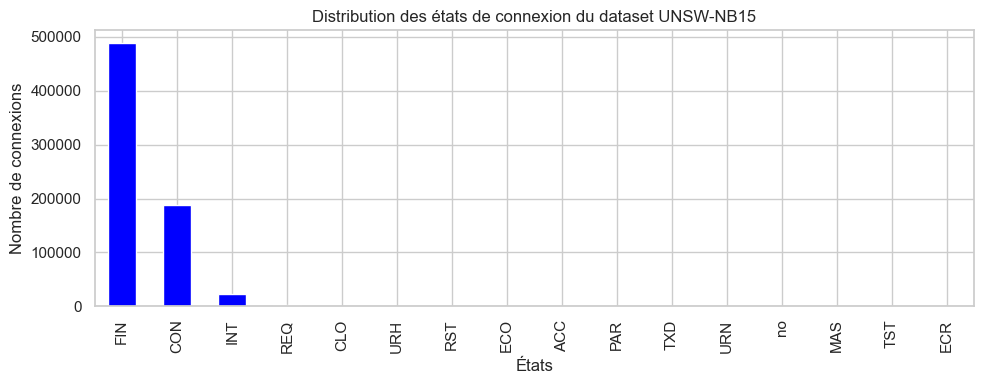

In [100]:
# Distribution des états de connexion (state)
fig, ax = plt.subplots()
state = df_unsw['state'].value_counts()
state.plot(kind='bar', color='blue')
ax.set_title('Distribution des états de connexion du dataset UNSW-NB15')
ax.set_xlabel('États')
ax.set_ylabel('Nombre de connexions')
plt.show()

Les états de connexion FIN avec environ 480 000 connexions et CON avec environ 190 000 dominent largement les autres états de connexion, on retrouve aussi INT avec environ 20 000 connexions. Les autres états possèdent pratiquement aucune connexion.
On note que FIN signifie que la connexion s'est terminée normalement.
CON indique une connexion établie et active au moment de la capture.
INT représente des connexions interrompues avant leur fin normale, ce qui peut être le signe de tentatives d'attaques.
Alors que les états de connexion comme RST, URH ou CLO peuvent révéler des comportements anormaux.

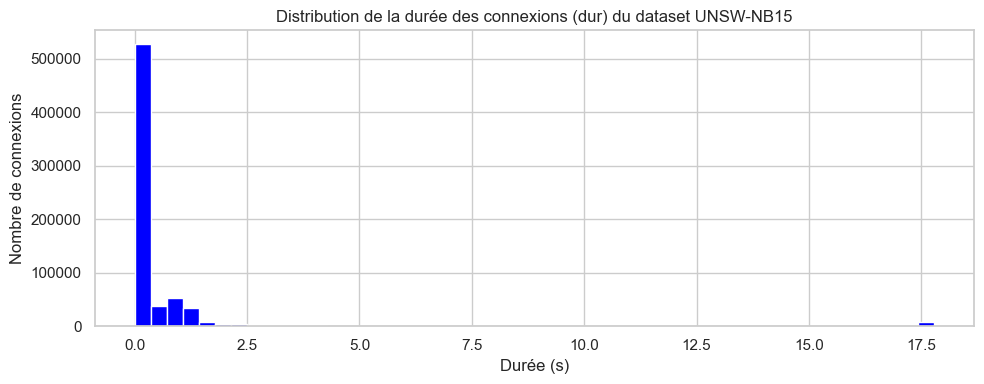

In [53]:
# Distribution de la durée des connexions (dur)
fig, ax = plt.subplots()
df_unsw['dur'].clip(upper=df_unsw['dur'].quantile(0.99)).hist(bins=50,color='blue')
ax.set_title('Distribution de la durée des connexions du dataset UNSW-NB15')
ax.set_xlabel('Durée (s)')
ax.set_ylabel('Nombre de connexions')
plt.tight_layout()
plt.show()

On remarque que la très grande majorité des connexions durent moins de 0,5 seconde, avec un pic massif à  environ 530 000 flux. On retrouve le même schéma que pour le dataset CIC-IDS-2017 avec une distribution très concentrée sur les courtes durées avec une longue traîne vers la droite.
La différence notable est l'unité car ici nous sommes en secondes, ainsi la base de données UNSW-NB15 représente un trafic plus varié. Les quelques connexions atteignant 17,5 secondes représentent probablement des sessions légitimes ou des attaques plus lentes et persistantes .


### 2.3 Déséquilibre des classes

       Nombre
Label        
0      677785
1       22215


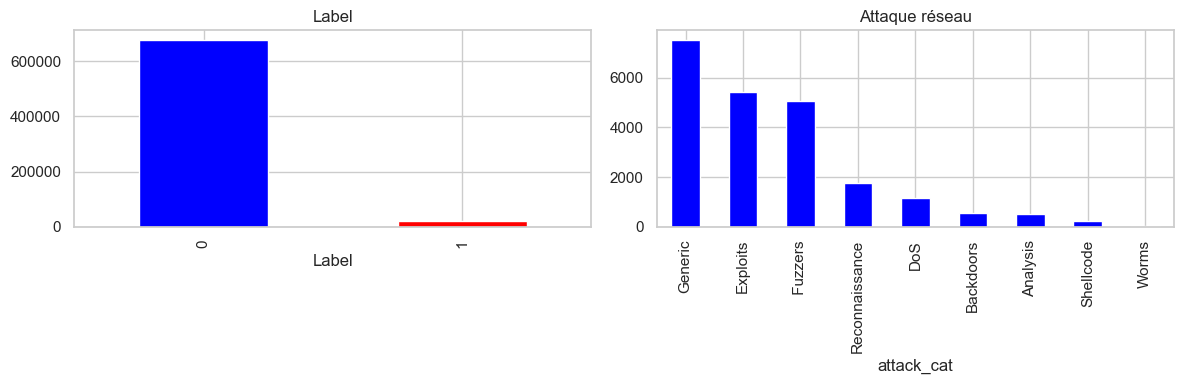

In [117]:
# Distribution des classes
print(pd.DataFrame({'Nombre': df_unsw['Label'].value_counts()}))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_unsw['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'red'], title='Label')
df_unsw['attack_cat'].value_counts().plot(kind='bar', ax=axes[1], color='blue', title='Attaque réseau')
plt.tight_layout()
plt.show()


Ici le déséquilibre est très prononcé on a  677 785 connexions normales (label 0) contre seulement 22 215 attaques (label 1). Lors des modélisations il faudra rééquilibrer la base de données afin de s'assurer que les modèles ne prédisent pas que des connexions normales.
Le second graphique sur les types d'attaques montre que Generic domine largement, suivi d'Exploits et Fuzzers. Les catégories DoS, Backdoors, Analysis, Shellcode et Worms sont bien plus rares.


## 3. Cybersecurity Threat Detection Logs

### 3.1 Statistiques descriptives

In [116]:
df_logs.describe(include='all')

,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
count,6000000,6000000,6000000,6000000,6000000,6000000,6000000,6.000000e+06,6000000,6000000
unique,365,354,254,7,2,3,3,NaN,5,228
top,2024-06-17T00:00:00,59.211.9.207,192.168.1.5,TCP,allowed,benign,application,NaN,curl/7.64.1,/
freq,16777,18295,24140,1497493,3000646,5517611,2001768,NaN,1200739,2741075
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.504649e+04,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.440163e+04,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+02,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.258400e+04,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.503600e+04,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.751900e+04,NaN,NaN


Le dataset des Logs compte 6 millions de lignes réparties sur 10 colonnes. On remarque que la majorité des colonnes sont catégorielles, ce qui explique les NaN sur les lignes mean/std/min/max.
TCP est le protocole le plus fréquent avec 1 497 493 occurrences parmi 7 protocoles distincts. L'action allowed est la plus courante avec 3 000 646 occurrences sur 2 valeurs possibles, ce qui signifie que la moitié du trafic est bloqué.
La seule colonne numérique est bytes_transferred avec une médiane à 25 036 octets et un maximum à 50 000 octets, ce qui indique une distribution relativement homogène comparée aux deux autres datasets.
user_agent ne possède que 5 valeurs uniques alors que dans un vrai environnement on en attendrait des centaines, cela confirme le caractère synthétique du dataset.
Concernant le déséquilibre des classes, benign domine avec 5 517 611 occurrences contre 360 000 suspects et 120 000 malveillants. Ce déséquilibre volontaire reflète la réalité d'un réseau d'entreprise mais devra être traité avant la modélisation.

### 3.2 Distribution des variables clés

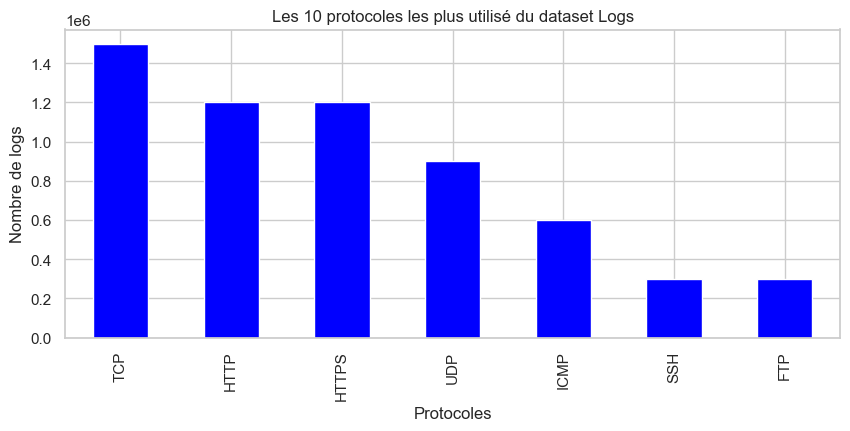

In [103]:
# Distribution des protocoles
fig, ax = plt.subplots()
protocol = df_logs['protocol'].value_counts().head(10)
protocol.plot(kind='bar',color='blue')
ax.set_title('Les 10 protocoles les plus utilisé du dataset Logs')
ax.set_xlabel('Protocoles')
ax.set_ylabel('Nombre de logs')
plt.show()

Le protocole TCP domine avec environ 1,5M de logs, puis suivi par HTTP et HTTPS avec environ 1,2M de logs chacun. UDP, ICMP, SSH et FTP sont présents mais bien moins représentés.
Contrairement aux deux autres datasets on remarque que la distribution ici est bien plus équilibrée entre les protocoles on ne retrouve aucun protocoles qui domine massivement les autres. Cela peut s'expliquer par le fait que ce dataset est bien synthétique et conçu pour couvrir uniformément différents scénarios de trafic réseau.

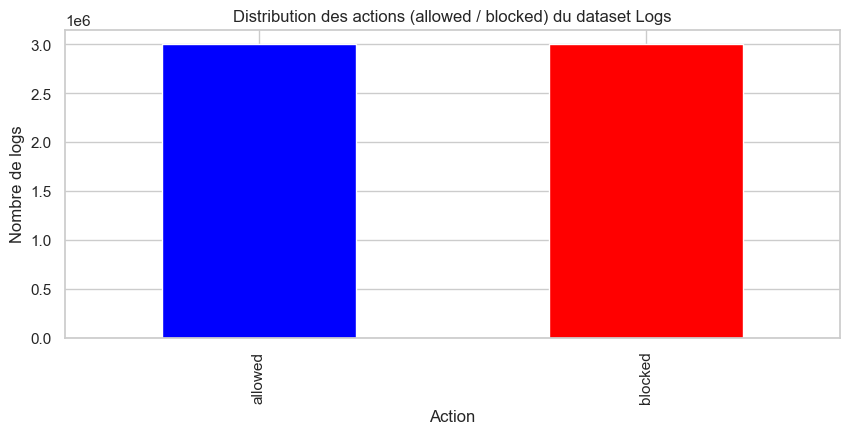

In [110]:
# Distribution des actions (allowed / blocked)
fig, ax = plt.subplots()
action = df_logs['action'].value_counts()
action.plot(kind='bar', color=['blue','red'])
ax.set_title('Distribution des actions (allowed / blocked) du dataset Logs')
ax.set_xlabel('Action')
ax.set_ylabel('Nombre de logs')
plt.show()

Ici les actions allowed et blocked sont parfaitement équilibrées à 3 millions chacune.

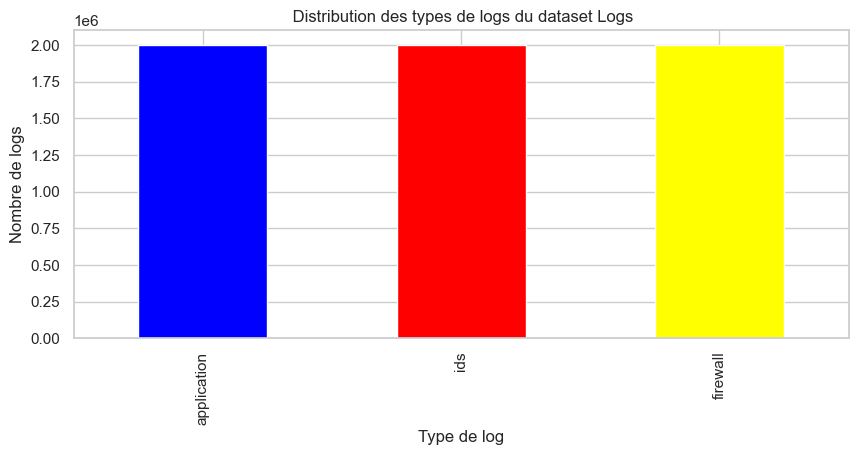

In [109]:
# Distribution des types de logs (log_type)
fig, ax = plt.subplots()
types = df_logs['log_type'].value_counts()
types.plot(kind='bar', color=['blue', 'red', 'yellow'])
ax.set_title(' Distribution des types de logs du dataset Logs')
ax.set_xlabel('Type de log')
ax.set_ylabel('Nombre de logs')
plt.show()

Les trois types de logs application, ids et firewall sont répartis de façon presque identique à 2 millions chacun. Dans un environnement réel, les logs firewall seraient généralement bien plus nombreux que les logs IDS ou applicatifs.

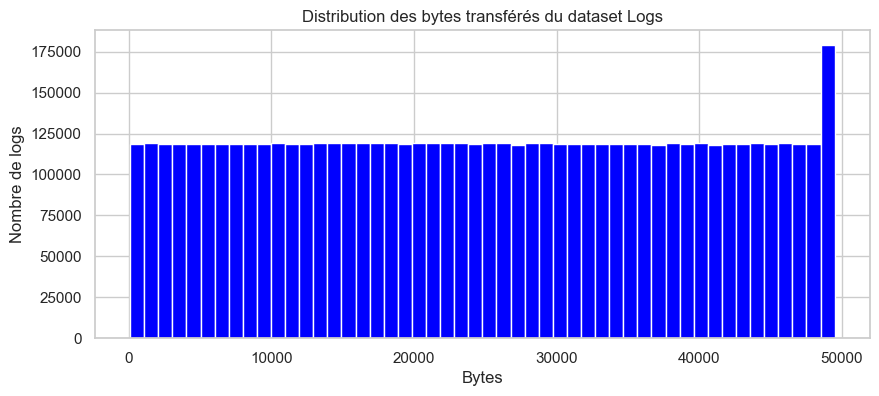

In [107]:
# Distribution des bytes transférés
fig, ax = plt.subplots()
df_logs['bytes_transferred'].clip(upper=df_logs['bytes_transferred'].quantile(0.99)).hist(bins=50,color='blue')
ax.set_title('Distribution des bytes transférés du dataset Logs')
ax.set_xlabel('Bytes')
ax.set_ylabel('Nombre de logs')
plt.show()

La distribution des bytes transférés est parfaitement uniforme entre 0 et 50 000 octets, avec 115 000 logs dans chaque intervalle. Le léger pic à 50 000 correspond à la valeur maximale du dataset.


### 3.3 Déséquilibre des classes

Distribution des classes :
              Nombre
log_type            
application  2001768
ids          1999556
firewall     1998676


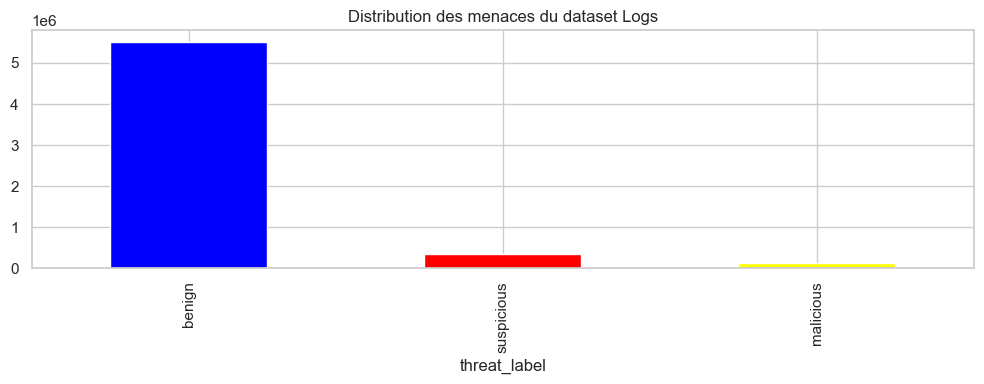

In [130]:
print('Distribution des classes :')
print(pd.DataFrame({'Nombre':types}))
fig, ax = plt.subplots()
df_logs['threat_label'].value_counts().plot(kind='bar',color=['blue', 'red', 'yellow'], title='Distribution des menaces du dataset Logs')
plt.tight_layout()
plt.show()

Cependant le dataset présente un déséquilibre avec 5,5M de logs bénins contre 360 000 suspects et seulement 120 000 malveillants .
Ici la variable cible reflète une distribution plus réaliste car les événements malveillants sont naturellement rares par rapport au trafic normal. 